In [1]:
import os
import numpy as np
import pandas as pd
import torch
import random

import sys
sys.path.append('/home/wergillius/Project/TIGON')
import utility 
from importlib import reload

from matplotlib import pyplot as plt


In [2]:
import scanpy as sc
import PINN
import palantir

In [3]:
import mellon

In [4]:
# ad
data_path = "/home/wergillius/Project/PINN_dynamics"
ad = sc.read_h5ad(f"{data_path}/data/tom_pos.h5ad")

In [5]:
ad

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [6]:
cb_t = ad.obs.query("`timepoint_tx_days` == 3").index
cs_t = ad[cb_t]

In [7]:
cs_t

View of AnnData object with n_obs × n_vars = 394 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_cli

In [ ]:
X = ad.obsm["DM_scaled"]
density_funs = []
log_u = []

for i, t in enumerate(ad.uns['pop']['t']):
    cb_t = ad.obs.query("`timepoint_tx_days` == @t").index
    cs_t = ad[cb_t].obsm["DM_scaled"]    # cellstate t

    model_t = mellon.DensityEstimator()
    model_t.fit(cs_t)

    log_density = model_t.predict(X)
    
    log_u.append(log_density)
    density_funs.append(model_t)

[2024-12-07 07:04:32,850] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (394) >= n_samples (394) and rank = 1.0.
[2024-12-07 07:04:32,850] [INFO    ] Computing nearest neighbor distances.
[2024-12-07 07:04:32,856] [INFO    ] Using embedding dimensionality d=30. Use d_method="fractal" to enable effective density normalization.
[2024-12-07 07:04:32,858] [INFO    ] Using covariance function Matern52(ls=0.5021298532406172).
[2024-12-07 07:04:32,872] [INFO    ] Using rank 394 covariance representation.
[2024-12-07 07:04:32,885] [INFO    ] Running inference using L-BFGS-B.
[2024-12-07 07:04:33,738] [INFO    ] Computing predictive function.
[2024-12-07 07:04:34,200] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (633) >= n_samples (633) and rank = 1.0.
[2024-12-07 07:04:34,200] [INFO    ] Computing nearest neighbor distances.
[2024-12-07 07:04:34,211] [INFO    ] Using embedding dimensionality d=30. Use d_method="fractal" to enable effective density normalizati

[2024-12-07 07:04:35,814] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (613) >= n_samples (613) and rank = 1.0.
[2024-12-07 07:04:35,815] [INFO    ] Computing nearest neighbor distances.
[2024-12-07 07:04:35,825] [INFO    ] Using embedding dimensionality d=30. Use d_method="fractal" to enable effective density normalization.
[2024-12-07 07:04:35,826] [INFO    ] Using covariance function Matern52(ls=0.5005165226756425).
[2024-12-07 07:04:35,840] [INFO    ] Using rank 613 covariance representation.
[2024-12-07 07:04:35,857] [INFO    ] Running inference using L-BFGS-B.
[2024-12-07 07:04:36,813] [INFO    ] Computing predictive function.
[2024-12-07 07:04:37,500] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (3,357) >= n_samples (3,357) and rank = 1.0.
[2024-12-07 07:04:37,501] [INFO    ] Computing nearest neighbor distances.
[2024-12-07 07:04:37,620] [INFO    ] Using embedding dimensionality d=30. Use d_method="fractal" to enable effective density normali

(9, 49390)
prediction of shape (9, 49390)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_log u\nmin:7.6e+01\nmax:1.23e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_log u\nmin:8.67e+01\nmax:1.21e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_log u\nmin:8.54e+01\nmax:1.19e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_log u\nmin:6.01e+01\nmax:1.33e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_log u\nmin:7.41e+01\nmax:1.3e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_log u\nmin:8.26e+01\nmax:1.34e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_log u\nmin:6.93e+01\nmax:1.36e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_log u\nmin:8.42e+01\nmax:1.34e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day269_log u\nmin:7.31e+01\nmax:1.41e+02'}, xlabel='UMAP1',

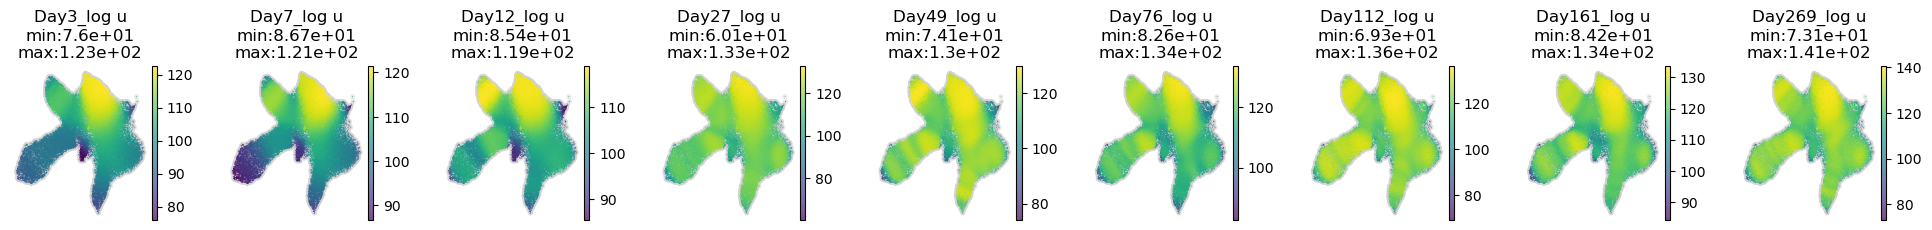

In [37]:
log_density_ay = np.stack(log_u)
print(log_density_ay.shape)
PINN.pl.params_in_umap(ad, log_density_ay, ad.uns['pop']['t'], param='log u', cell_of_t=False)

(9, 49390)
prediction of shape (9, 49390)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_log u\nmin:7.6e+01\nmax:1.23e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_log u\nmin:8.67e+01\nmax:1.21e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_log u\nmin:8.54e+01\nmax:1.19e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_log u\nmin:6.01e+01\nmax:1.33e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_log u\nmin:7.41e+01\nmax:1.3e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_log u\nmin:8.26e+01\nmax:1.34e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_log u\nmin:6.93e+01\nmax:1.36e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_log u\nmin:8.42e+01\nmax:1.34e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day269_log u\nmin:7.31e+01\nmax:1.41e+02'}, xlabel='UMAP1',

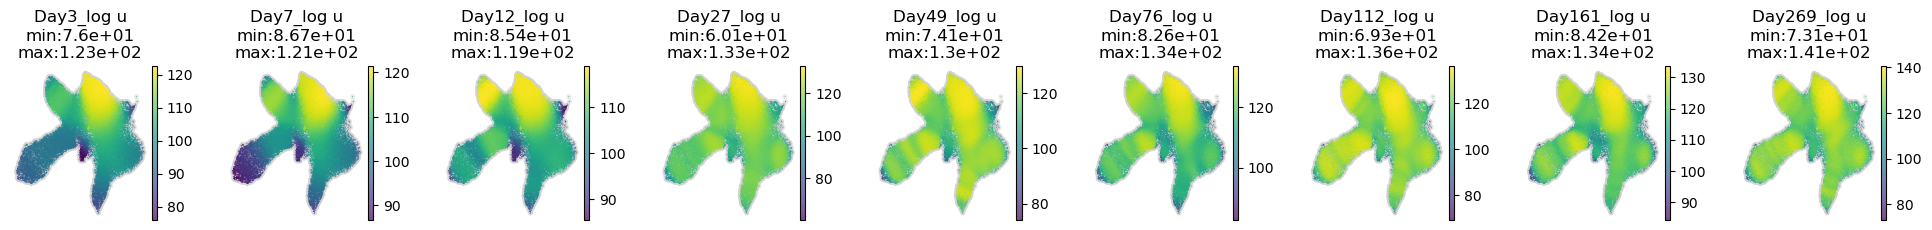

In [ ]:
PINN.pl.params_in_umap(ad, np.stack(log_u), ad.uns['pop']['t'], param='\nlog u \n DM scaled \n', cell_of_t=False)

(9, 49390)
prediction of shape (9, 49390)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_\nlog u \n PCA harmony \n\nmin:-1.41e+02\nmax:-1.24e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_\nlog u \n PCA harmony \n\nmin:-1.26e+02\nmax:-1.09e+02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_\nlog u \n PCA harmony \n\nmin:-1.49e+02\nmax:-9.12e+01'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_\nlog u \n PCA harmony \n\nmin:-1.98e+02\nmax:-7.4e+01'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_\nlog u \n PCA harmony \n\nmin:-1.55e+02\nmax:-6.48e+01'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_\nlog u \n PCA harmony \n\nmin:-1.55e+02\nmax:-6.77e+01'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_\nlog u \n PCA harmony \n\nmin:-1.50e+02\nmax:-5.3e+01'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_\nlog u 

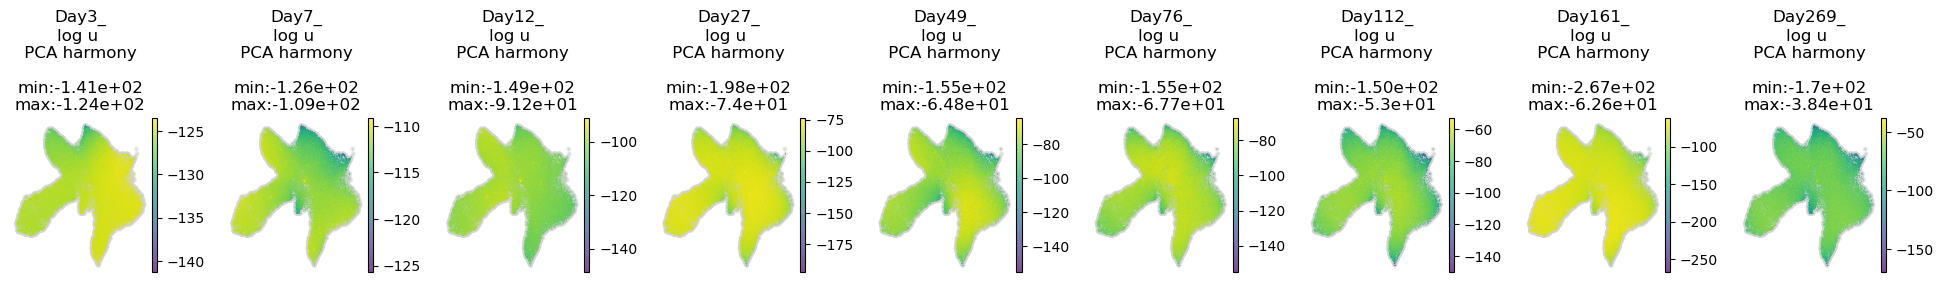

In [ ]:
PINN.pl.params_in_umap(ad, np.stack(log_u), ad.uns['pop']['t'], param='\nlog u \n PCA harmony \n', cell_of_t=False)

In [23]:
predictor_t = model_t.predict

In [24]:
dloguds = predictor_t.gradient(X) - 169.7956754

In [25]:
duds = np.multiply(u[-1].reshape(-1,1), dloguds)

In [26]:
duds.shape

(49390, 30)

In [50]:
np.quantile(duds, np.linspace(0,1,2), axis=0)

array([[-1.83337465e+01, -3.28117251e+01, -1.71705229e-07,
        -6.14632694e-08, -1.38700025e+01, -3.42379474e+00,
        -1.37065369e-07, -3.95410781e+01, -5.63831498e+01,
        -8.70012884e+00, -3.05063301e+01, -3.16860991e+01,
        -1.26061793e+01, -1.28374613e-07, -3.26311304e+01,
        -1.25830333e-07, -7.75432610e+00, -8.62479916e+00,
        -2.73494186e+01, -2.34039926e+01, -1.76308196e+01,
        -3.12151322e+01, -1.66594073e+01, -1.53359001e+01,
        -1.74815304e+01, -2.32600711e+01, -2.79124184e+01,
        -1.97801780e+00, -3.69690224e+01, -3.89557263e+01],
       [-1.15375494e-53, -1.13152004e-53,  9.83537493e+00,
         4.03315726e+00, -1.16187727e-53,  9.18686934e-07,
         6.69889927e+00,  4.29932120e-10, -1.06003962e-53,
         8.54137678e-09,  4.45265472e-14, -1.15084656e-53,
        -1.10170345e-53,  1.75011321e+01,  2.51836368e-14,
         9.94978521e+00,  2.63115932e-09,  1.36699387e-13,
        -1.14110355e-53,  2.32411803e-16, -1.14042959e-

prediction of shape (9, 49390)


prediction of shape (9, 49390)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_u\nmin:1.83e+54\nmax:1.77e+89'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_u\nmin:2.67e+64\nmax:2.47e+90'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_u\nmin:1.44e+59\nmax:6.28e+91'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_u\nmin:2.49e+37\nmax:3.98e+103'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_u\nmin:5.09e+62\nmax:3.37e+104'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_u\nmin:6.19e+65\nmax:1.46e+109'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_u\nmin:2.49e+54\nmax:6.97e+112'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_u\nmin:2.72e+45\nmax:9.4e+108'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day269_u\nmin:9.5e+61\nmax:6.09e+116'}, xlabel='UMAP1', ylabel='UMAP2'>],
       dtyp

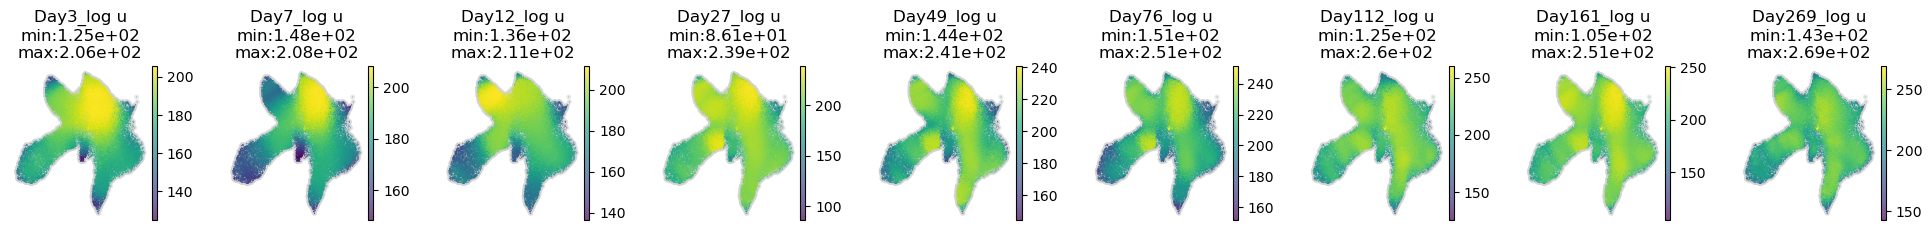

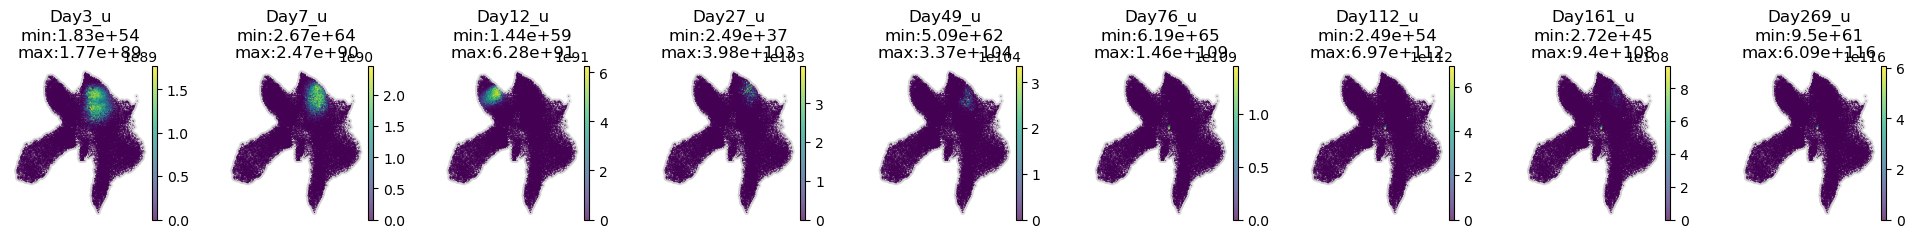

In [35]:
PINN.pl.params_in_umap(ad, log_density_ay, ad.uns['pop']['t'], param='log u', cell_of_t=False)
PINN.pl.params_in_umap(ad, np.exp(log_density_ay), ad.uns['pop']['t'], param='u',  cell_of_t=False)

In [28]:
u = np.exp(log_density_ay)
u = u / u.sum(axis=1).reshape(-1,1)

In [29]:
log_u_recomputed = np.log(u)

In [30]:
log_density_ay - log_u_recomputed 

array([[212.97358738, 212.97358738, 212.97358738, ..., 212.97358738,
        212.97358738, 212.97358738],
       [215.14109028, 215.14109028, 215.14109028, ..., 215.14109028,
        215.14109028, 215.14109028],
       [217.94180996, 217.94180996, 217.94180996, ..., 217.94180996,
        217.94180996, 217.94180996],
       ...,
       [262.25659336, 262.25659336, 262.25659336, ..., 262.25659336,
        262.25659336, 262.25659336],
       [254.57809473, 254.57809473, 254.57809473, ..., 254.57809473,
        254.57809473, 254.57809473],
       [270.97544546, 270.97544546, 270.97544546, ..., 270.97544546,
        270.97544546, 270.97544546]])

In [31]:
np.quantile(log_u_recomputed, np.linspace(0,1,10))

array([-157.19342114,  -51.31073524,  -42.62628735,  -37.27433415,
        -33.05430543,  -29.40739614,  -25.61722313,  -21.66869153,
        -16.42742698,   -2.33822443])

prediction of shape (9, 49390)


prediction of shape (9, 49390)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_u\nmin:2.45e-26\nmax:5.7e-04'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_u\nmin:2.45e-26\nmax:9.09e-04'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_u\nmin:2.45e-26\nmax:1.40e-03'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_u\nmin:2.45e-26\nmax:8.6e-03'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_u\nmin:2.45e-26\nmax:1.23e-02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_u\nmin:2.45e-26\nmax:7.16e-02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_u\nmin:2.45e-26\nmax:8.85e-02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_u\nmin:2.45e-26\nmax:2.57e-02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day269_u\nmin:2.45e-26\nmax:9.65e-02'}, xlabel='UMAP1', ylabel='UMAP2'>],
       dtype=obje

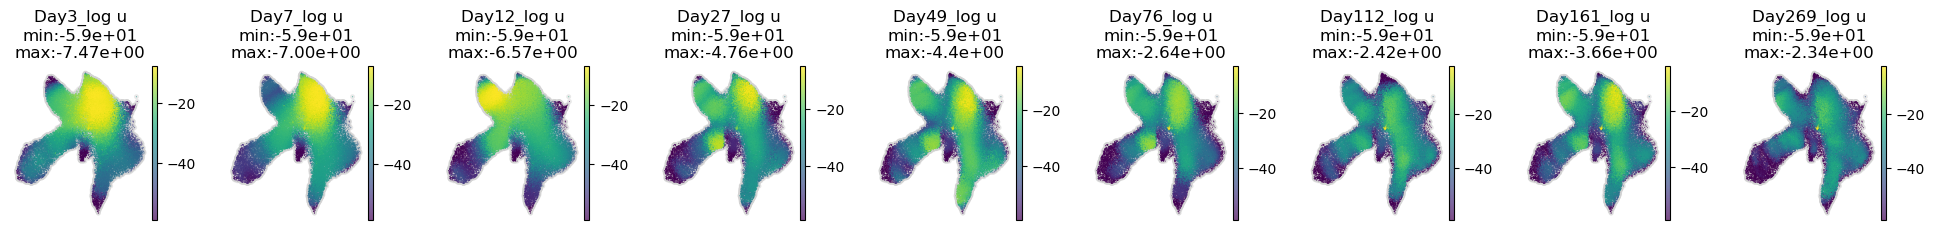

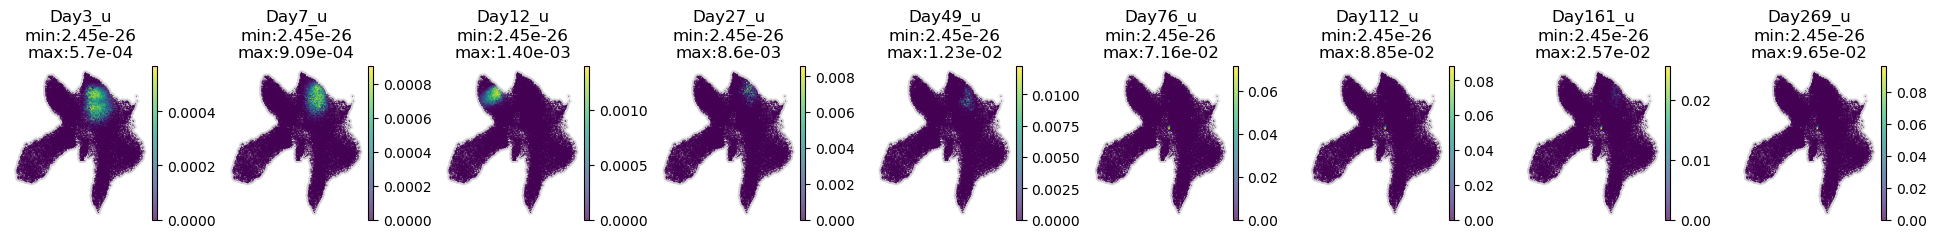

In [32]:
log_u_recomputed_clip = np.clip(log_u_recomputed, *np.quantile(log_u_recomputed, [0.05, 1]))
PINN.pl.params_in_umap(ad, log_u_recomputed_clip, ad.uns['pop']['t'], param='log u', cell_of_t=False)
PINN.pl.params_in_umap(ad, np.exp(log_u_recomputed_clip), ad.uns['pop']['t'], param='u',  cell_of_t=False)

In [ ]:
ad

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [ ]:
predictor.gradient(X)

In [ ]:

X_times = ad.obs["timepoint_tx_days"]

# this code is here to prevent accidental usage of default values on new data
ls_time_estimate = 1.5 * np.mean(np.diff(np.sort(X_times.unique())))
if 0.37 > ls_time_estimate or ls_time_estimate > 0.38:
    raise ValueError(
        "You time increments are very different from the tutorial data. "
        "Please choose amn appropriate time span or pass ls_time=None (takes long)."
    )

ValueError: You time increments are very different from the tutorial data. Please choose amn appropriate time span or pass ls_time=None (takes long).

In [14]:
# Initialize the time-sensitive density estimator with an intrinsic dimensionality of 2
t_est = mellon.TimeSensitiveDensityEstimator(d=2, ls_time=None)

# Fit the estimator to the data
t_est.fit(X, X_times)
density_predictor = t_est.predict

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[2024-06-11 04:20:45,862] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (130,700) and rank = 1.0.
[2024-06-11 04:20:45,863] [INFO    ] Computing nearest neighbor distances within time points.
[2024-06-11 04:21:20,797] [INFO    ] Initiating density computation for each time point to estimate the 'ls_time' parameter. You can directly specify 'ls_time' to bypass this computation-intensive step.
[2024-06-11 04:21:20,854] [INFO    ] [1 of 9] Computing density for 7,021 cells at time point 3.0.
[2024-06-11 04:21:20,892] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (7,021) and rank = 1.0.
[2024-06-11 04:21:20,893] [INFO    ] Using covariance function Matern52(ls=0.006933665668915388).
[2024-06-11 04:21:20,894] [INFO    ] Computing 5,000 landmarks with k-means clustering.
[2024-06-11 04:21:27,533] [INFO    ] Using rank 5,000 covariance representation.
[2024-06-11 04:21:29,210] [INFO    ] Running inference using L-BFGS-B.
[2024-

TimeSensitiveDensityEstimator(
    cov_func_curry=<class 'mellon.cov.Matern52'>,
    n_landmarks=5000,
    rank=1.0,
    gp_type=GaussianProcessType.SPARSE_CHOLESKY,
    jitter=1e-06, 
    optimizer=L-BFGS-B,
    landmarks=<array 5,000 landmarks x 31 dims, dtype=float64>,
    nn_distances=<array 130,700 cells, dtype=float64>,
    normalize_per_time_point=False,
    d=2.0,
    mu=0.6906611263575613,
    ls=0.006933665668915388,
    ls_time=1318815734.4832146,
    ls_factor=1.0,
    ls_time_factor=1.0,
    density_estimator_kwargs={},
    cov_func=(Matern52(active_dims=slice(None, -1, None), ls=0.006933665668915388) * Matern52(active_dims=-1, ls=1318815734.4832146)),
    Lp=<array 5,000 landmarks x 5,000 landmarks, dtype=float64>,
    L=<array 130,700 cells x 5,000 ranks, dtype=float64>,
    initial_value=<array 5,000 ranks, dtype=float64>,
    predictor_with_uncertainty=False,
    jit=False,
    check_rank=None,
)

In [ ]:
X_times.unique()

array([269, 161,   7,   3,  27,  12,  76,  49, 112])

In [28]:
plt.rcParams["figure.dpi"] = 80

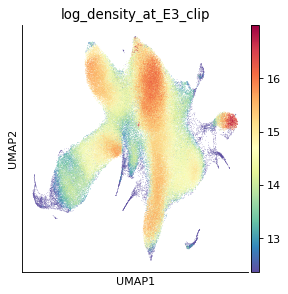

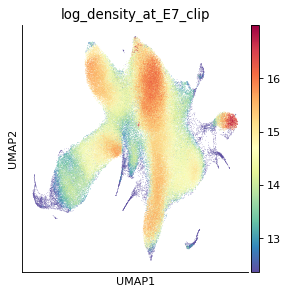

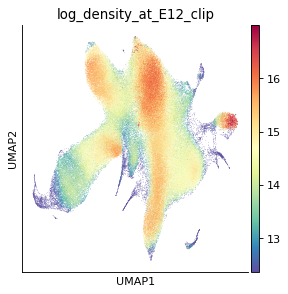

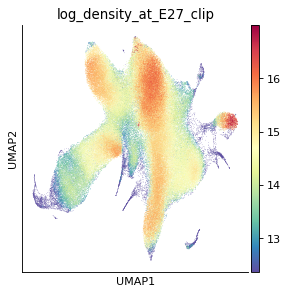

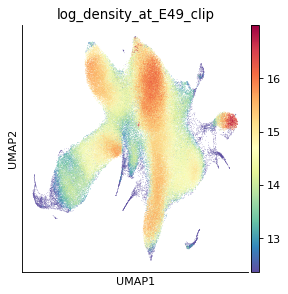

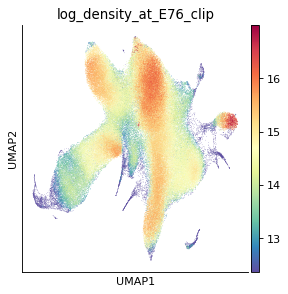

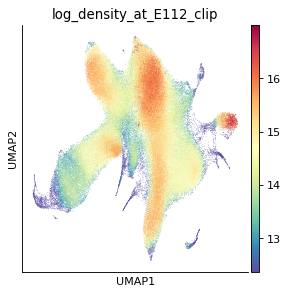

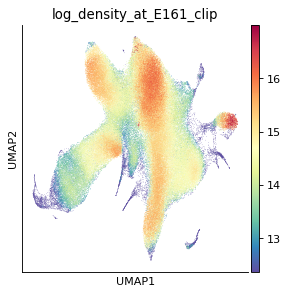

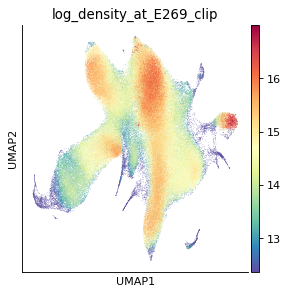

In [29]:
for time in sorted(X_times.unique()):
    log_density = density_predictor(X, time)
    ad.obs[f"log_density_at_E{time}"] = log_density
    ad.obs[f"log_density_at_E{time}_clip"] = np.clip(
        log_density, *np.quantile(log_density, [0.05, 1])
    )
    sc.pl.umap(ad,color=f"log_density_at_E{time}_clip")

In [30]:
ad.uns["density_predictor"] = density_predictor.to_dict()

In [31]:
data_path = "/home/wergillius/Project/HSPCdynamics/procdata/04script/"
ad.write_h5ad(f"{data_path}/combined_filt.h5ad")

# Infer with smoothed time point

In [6]:
X_times = ad.obs["timepoint_tx_days"]

In [7]:
ad.obs["smooth_days"] = ad.obs["timepoint_tx_days"].astype(str).map({
    "3":3,
    "7":7,
    "12":12,
    "27":17,
    "49":22,
    "76":27,
    "112":32,
    "161":37,
    "269":42
})

In [8]:
np.sort(X_times.unique())

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [9]:
X = ad.obsm["DM_EigenVectors"]
X_times = ad.obs["smooth_days"]

# this code is here to prevent accidental usage of default values on new data
ls_time_estimate = 1.5 * np.mean(np.diff(np.sort(X_times.unique())))
# if 0.37 > ls_time_estimate or ls_time_estimate > 0.38:
#     raise ValueError(
#         "You time increments are very different from the tutorial data. "
#         "Please choose amn appropriate time span or pass ls_time=None (takes long)."
#     )
print(ls_time_estimate)

7.3125


In [10]:
# Initialize the time-sensitive density estimator with an intrinsic dimensionality of None
t_est2 = mellon.TimeSensitiveDensityEstimator(d=None, ls_time=ls_time_estimate)

# Fit the estimator to the data
t_est2.fit(X, X_times)
density_predictor2 = t_est2.predict

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[2024-06-11 16:45:26,821] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (130,700) and rank = 1.0.
[2024-06-11 16:45:26,850] [INFO    ] Computing nearest neighbor distances within time points.
[2024-06-11 16:46:02,448] [INFO    ] Using covariance function (Matern52(active_dims=slice(None, -1, None), ls=0.006933665668915388) * Matern52(active_dims=-1, ls=7.3125)).
[2024-06-11 16:46:02,660] [INFO    ] Computing 5,000 landmarks with k-means clustering.
[2024-06-11 16:49:01,168] [INFO    ] Estimating approximation accuracy since 130,700 samples are more than 10 x 5,000 landmarks.
[2024-06-11 16:50:20,460] [INFO    ] Rank fraction (72.3%, lower is better) is within acceptable range. Current settings should provide satisfactory model performance.
[2024-06-11 16:50:20,462] [INFO    ] Using rank 5,000 covariance representation.
[2024-06-11 16:50:31,493] [INFO    ] Running inference using L-BFGS-B.
[2024-06-11 17:02:19,629] [INFO    ] Computing predictive functio

NameError: name 't_est' is not defined

In [11]:
density_predictor2 = t_est2.predict

In [12]:
ad2 = ad.copy()

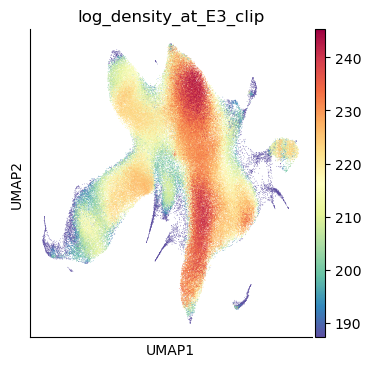

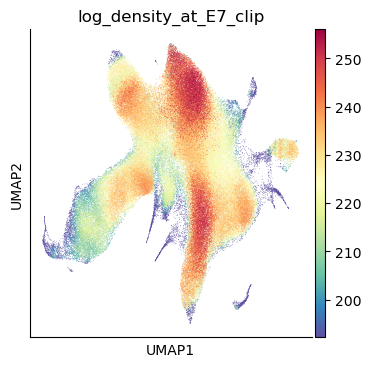

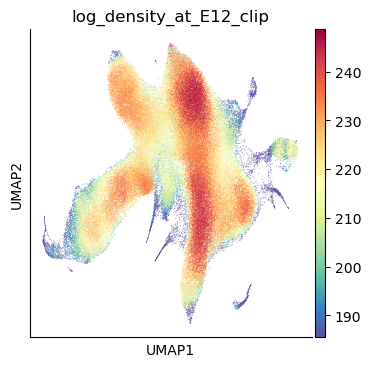

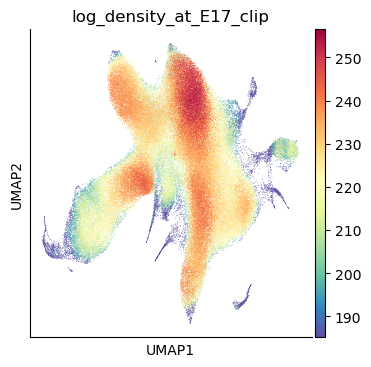

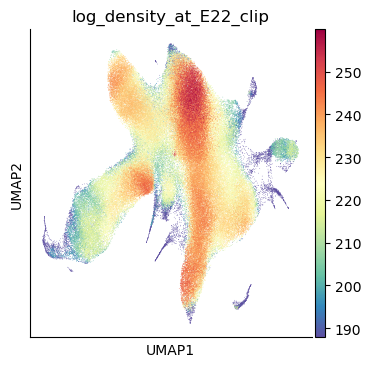

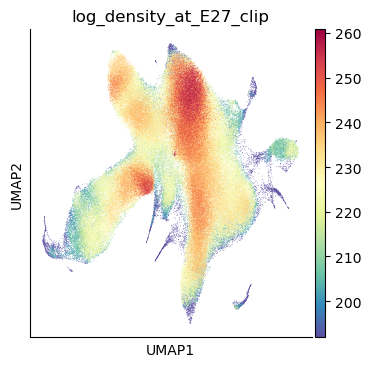

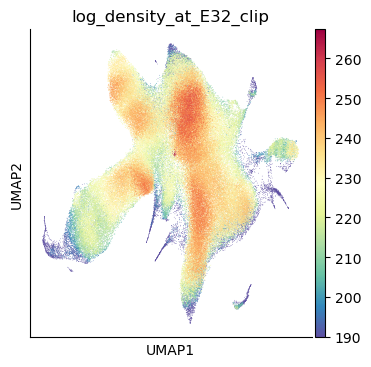

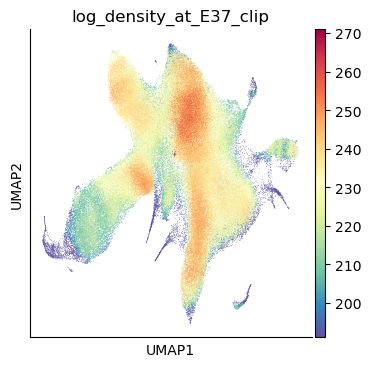

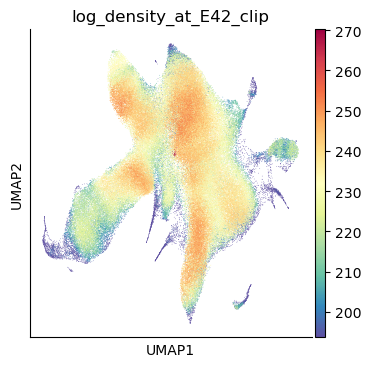

In [14]:
for time in sorted(X_times.unique()):
    log_density = density_predictor2(X, time)
    ad2.obs[f"log_density_at_E{time}"] = log_density
    ad2.obs[f"log_density_at_E{time}_clip"] = np.clip(
        log_density, *np.quantile(log_density, [0.05, 1])
    )
    sc.pl.umap(ad2,color=f"log_density_at_E{time}_clip")

In [15]:
ad2.uns["density_predictor"] = density_predictor2.to_dict()

In [16]:
data_path = "/home/wergillius/Project/HSPCdynamics/procdata/04script/"
ad2.write_h5ad(f"{data_path}/combined_filt_dNone.h5ad")

# get out cluster 7

In [ ]:
clu7_ad = ad2[CBs].copy()

7.3125


In [18]:
color_cols = [f"log_density_at_E{time}_clip" for time in sorted(X_times.unique())]

In [21]:
plt.rcParams["figure.dpi"] = 80

In [26]:
import plotting_fn as plfn

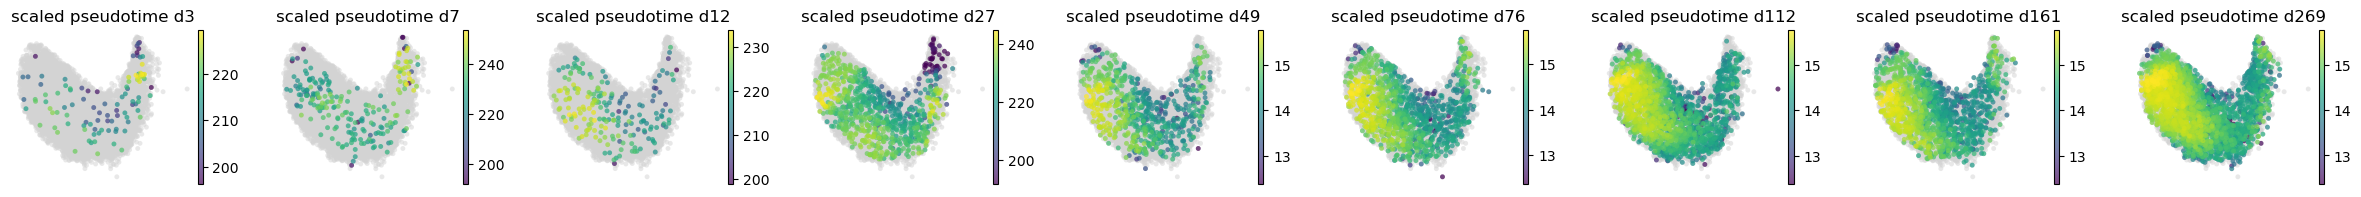

In [24]:
fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
# axs = axs.flatten()
axis_j = 0

for t in timepoints:
    cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index

    sc.pl.umap(clu7_ad, show=False, return_fig=False,  ax=axs[axis_j], alpha=0.5, s=50,frameon=False);
    sc.pl.umap(clu7_ad[cbs], color=f"log_density_at_E{t}_clip", alpha=0.7, color_map='viridis', 
            return_fig=False,show=False, ax=axs[axis_j], s=50, frameon=False, 
            title='scaled pseudotime d%d'%t);

    axis_j += 1

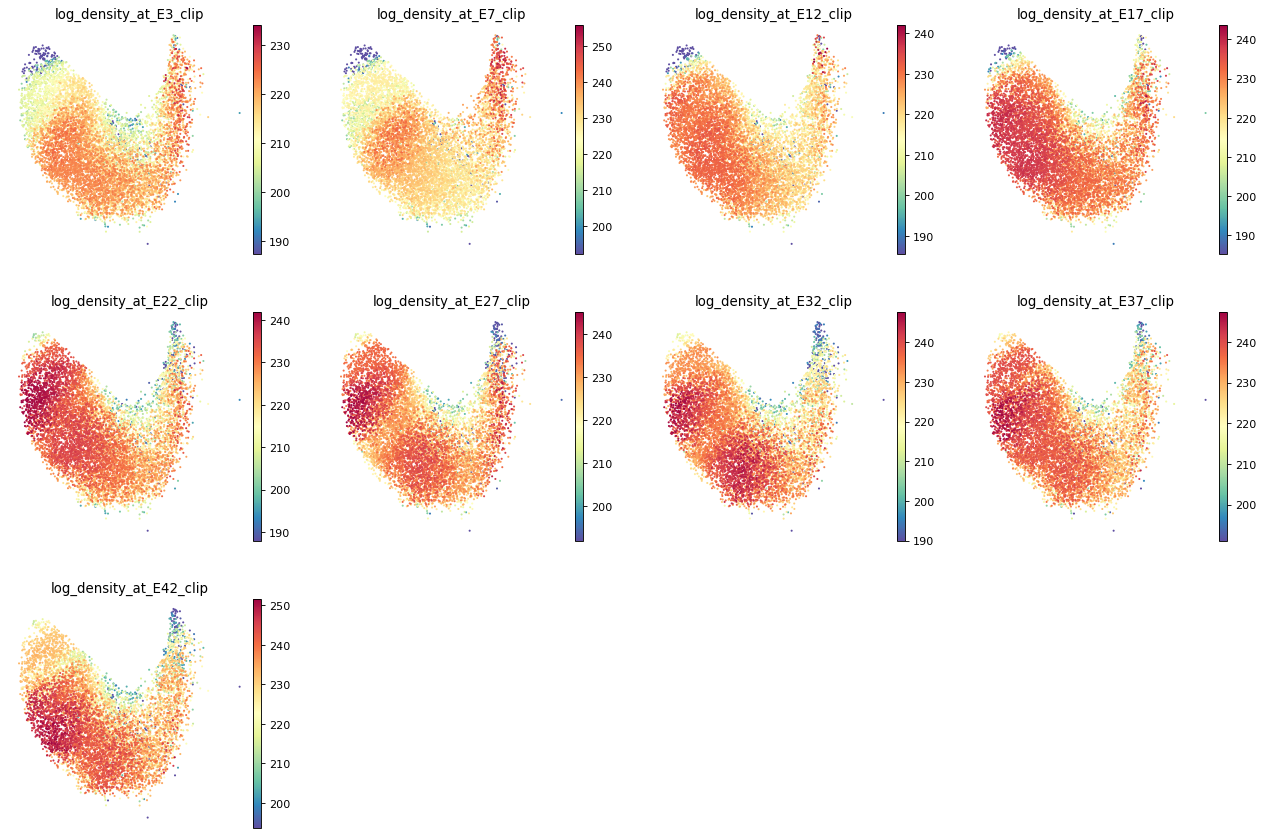

In [22]:
sc.pl.umap(clu7_ad, color=color_cols, frameon=False)

# fit on cluster 7

In [29]:
clu7_ad = ad2[CBs].copy()

X = clu7_ad.obsm["DM_EigenVectors"]
X_times = clu7_ad.obs["smooth_days"]

# this code is here to prevent accidental usage of default values on new data
ls_time_estimate = 1.5 * np.mean(np.diff(np.sort(X_times.unique())))
# if 0.37 > ls_time_estimate or ls_time_estimate > 0.38:
#     raise ValueError(
#         "You time increments are very different from the tutorial data. "
#         "Please choose amn appropriate time span or pass ls_time=None (takes long)."
#     )
print(ls_time_estimate)

7.3125


In [30]:
# Initialize the time-sensitive density estimator with an intrinsic dimensionality of None
t_est = mellon.TimeSensitiveDensityEstimator(d=None, ls_time=ls_time_estimate)

# Fit the estimator to the data
t_est.fit(X, X_times)
density_predictor = t_est.predict

[2024-06-11 22:49:04,144] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (8,704) and rank = 1.0.
[2024-06-11 22:49:04,218] [INFO    ] Computing nearest neighbor distances within time points.
[2024-06-11 22:49:07,432] [INFO    ] Using covariance function (Matern52(active_dims=slice(None, -1, None), ls=0.0075050301676791685) * Matern52(active_dims=-1, ls=7.3125)).
[2024-06-11 22:49:07,566] [INFO    ] Computing 5,000 landmarks with k-means clustering.
[2024-06-11 22:49:15,865] [INFO    ] Using rank 5,000 covariance representation.
[2024-06-11 22:49:17,757] [INFO    ] Running inference using L-BFGS-B.
[2024-06-11 22:49:42,698] [INFO    ] Computing predictive function.


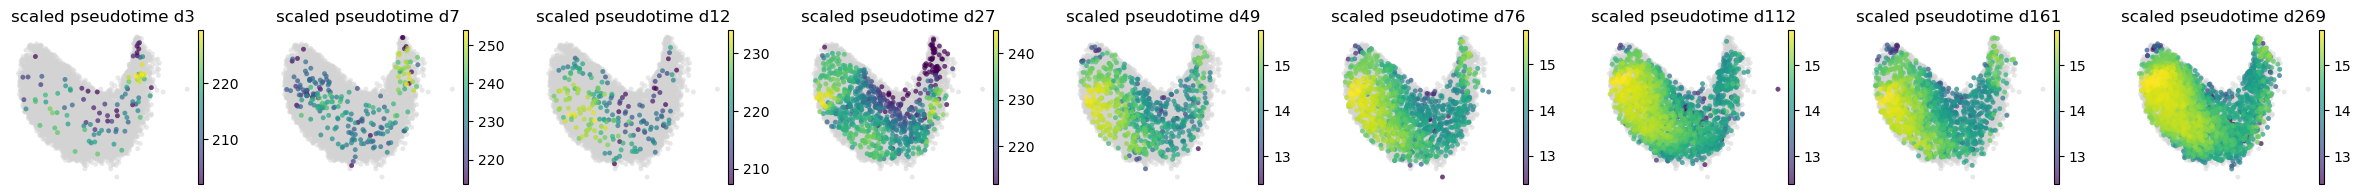

In [31]:
for time in sorted(X_times.unique()):
    log_density = density_predictor2(X, time)
    clu7_ad.obs[f"log_density_at_E{time}"] = log_density
    clu7_ad.obs[f"log_density_at_E{time}_clip"] = np.clip(
        log_density, *np.quantile(log_density, [0.05, 1])
    )
    

fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
# axs = axs.flatten()
axis_j = 0

for t in timepoints:
    cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index

    sc.pl.umap(clu7_ad, show=False, return_fig=False,  ax=axs[axis_j], alpha=0.5, s=50,frameon=False);
    sc.pl.umap(clu7_ad[cbs], color=f"log_density_at_E{t}_clip", alpha=0.7, color_map='viridis', 
            return_fig=False,show=False, ax=axs[axis_j], s=50, frameon=False, 
            title='log_density_at d%d'%t);

    axis_j += 1

In [34]:
import seaborn as sns

ValueError: Could not interpret value `dpt_pseudotime_scaled` for `x`. An entry with this name does not appear in `data`.

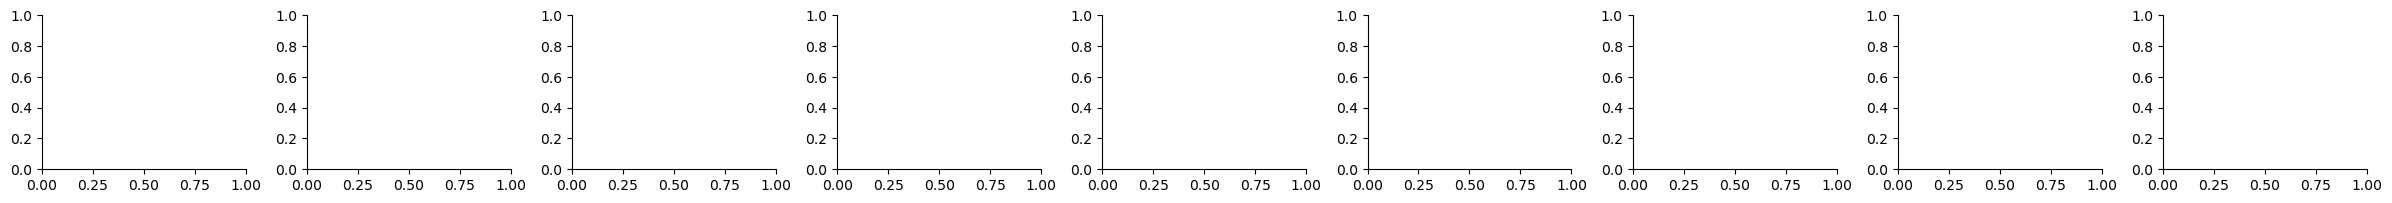

In [35]:
fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
    # axs = axs.flatten()
axis_j = 0

for t in timepoints:
    cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index
    sns.scatterplot(data=clu7_ad.obs.loc[cbs], x='dpt_pseudotime_scaled', y = f"log_density_at_E{t}_clip", ax=axs[axis_j])
    axis_j += 1

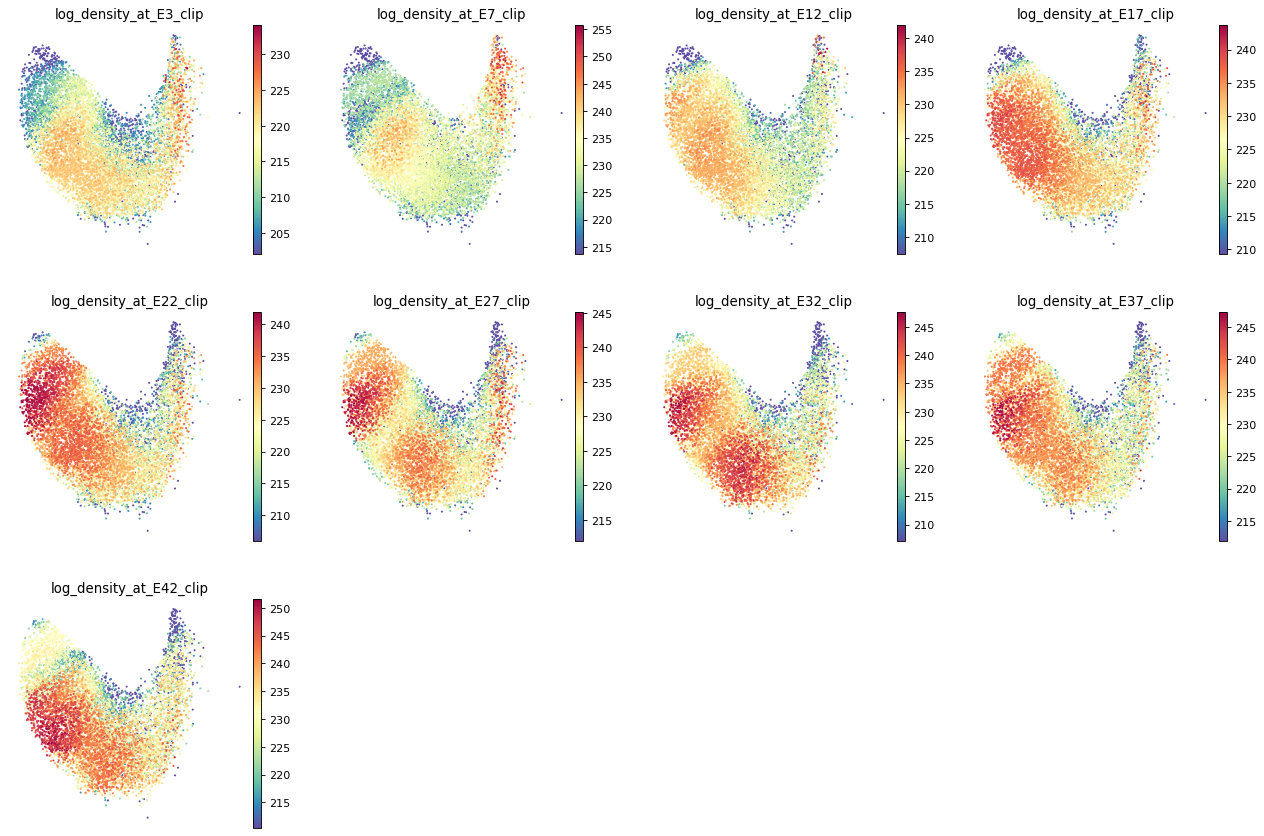

In [32]:
sc.pl.umap(clu7_ad, color=color_cols, frameon=False)

# for cluster 7 and 11